In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day48-simple-linear-regression/placement.csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


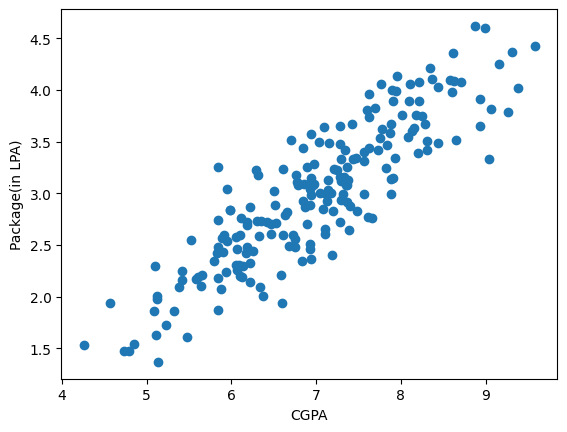

In [3]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in LPA)')
plt.show()

In [7]:
X = df.iloc[:,0:1]
y=df.iloc[:,-1]

In [8]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [9]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


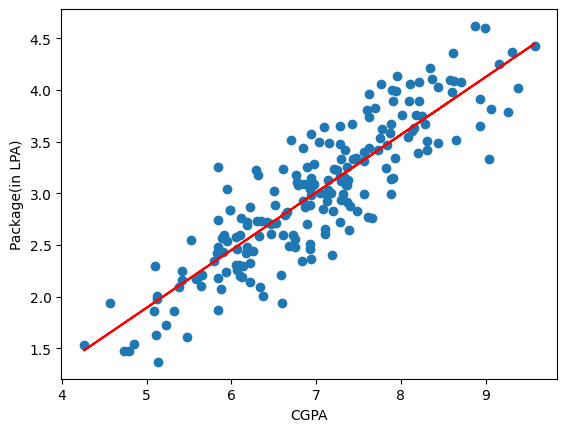

In [10]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in LPA)')
plt.show()

In [11]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [12]:
y_pred = lr.predict(X_test)

In [14]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2 Score",r2_score(y_test,y_pred))

MAE 0.2884710931878175
MSE 0.12129235313495527
RMSE 0.34827051717731616
R2 Score 0.780730147510384


In [15]:
# Adjusted R2 Score
r2 = r2_score(y_test,y_pred)
print('Adjusted R2 Score',1-((1-r2)*(40-1)/(40-1-1)))

Adjusted R2 Score 0.7749598882343415


In [45]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.571472,3.26
1,5.12,0.197940,1.98
2,7.82,0.410323,3.25
3,7.42,0.330191,3.67
4,6.94,0.436782,3.57


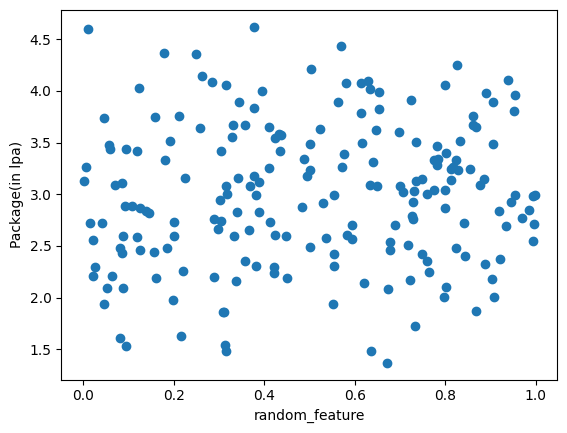

In [46]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')
plt.show()

In [47]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [48]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [49]:
lr = LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
y_pred = lr.predict(X_test)

In [51]:
print('R2 Score',r2_score(y_test,y_pred))

R2 Score 0.7810692082673141


In [52]:
r2 = r2_score(y_test,y_pred)
1-((1-r2)*(40-1)/(40-1-2))

0.7692351114168986

Adjusted R2 score decreased because a completely irrelevant feature was added in our training model

In [38]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]


new_df2.sample(5)

,cgpa,iq,package
29,7.15,3.39,3.49
31,8.10,4.69,3.89
100,7.95,5.14,4.14
96,7.11,2.31,2.61
2,7.82,3.05,3.25


Text(0, 0.5, 'Package(in lpa)')

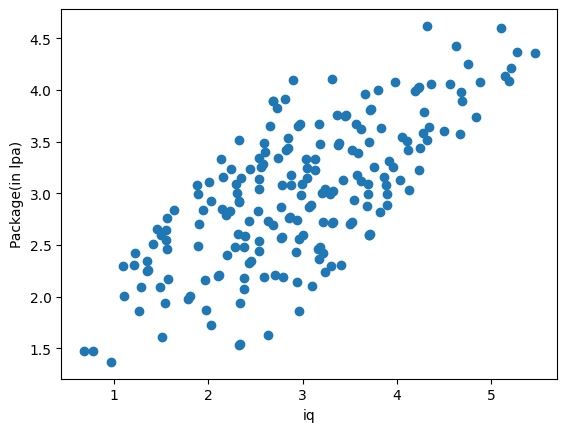

In [39]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [40]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [41]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [42]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [43]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.8163810536358281


In [44]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.8064557051837107

Adjusted R2 score increased as we added a column/feature that is relevant to our dataframe